# Mesh operations with meshio++ (Julia)

Julia counterpart of [`03_mesh_operations.ipynb`](../cpp/03_mesh_operations.ipynb): the same tour of
meshio++'s dependency-free **operations layer**, called through the `MeshioPlusPlus` Julia package instead
of the C++ core directly. Every operation shown here is the exact function the Python/C-API/Fortran/WASM
bindings and the CLI verbs all call into — this binding rides on the same flat C API as Fortran and R.

As in [`01_read_and_visualize.ipynb`](./01_read_and_visualize.ipynb): no PyVista, and no per-call SVG
colouring either (a flat-ABI gap, not a choice) — renders are plain, and where the C++ notebook colours a
mesh by a metric or field, this one shows a small hand-rolled chart instead.

In [1]:
ENV["MESHIOPLUSPLUS_LIB"] = joinpath(@__DIR__, "..", "..", "inst-nohdf5", "lib", "libmeshioplusplus.so")
import Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", "bindings", "julia", "MeshioPlusPlus"))
using MeshioPlusPlus
import MeshioPlusPlus as mio
include("mio_notebook.jl")

mesh = mio.read(joinpath(@__DIR__, "example.vtu"))
println("points: ", num_points(mesh), ", triangles: ", cell_block_info(mesh, 1).num_cells,
        ", tetrahedra: ", cell_block_info(mesh, 2).num_cells)

  Activating 

points: 52282

project at `~/src/meshioplusplus/bindings/julia/MeshioPlusPlus`


, triangles: 58394, tetrahedra: 235014


## Surface / skin extraction

`extract_surface` picks the boundary automatically from the mesh's own highest-dimension cells (here: the
tetrahedra); `extract_skin` is the volume-only variant with an explicit `linearize` flag. Both share the
same code path.

surface: triangle

 x 58394
skin   : triangle x 58394


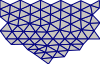

In [2]:
surface = extract_surface(mesh)
skin = extract_skin(mesh; linearize=true)
println("surface: ", cell_block_type(surface, 1), " x ", cell_block_info(surface, 1).num_cells)
println("skin   : ", cell_block_type(skin, 1), " x ", cell_block_info(skin, 1).num_cells)

# A vector figure's size scales with facet count (unlike a raster PNG), so renders below crop to a legible
# corner -- the same trade-off documented for tools/gen_doc_images.py.
vs = stats(surface)
viz_lo, viz_hi = collect(vs.bbox_min), collect(vs.bbox_max)
viz_corner_hi = viz_lo .+ (viz_hi .- viz_lo) .* 0.35
viz_corner = crop_bbox(surface, viz_lo, viz_corner_hi)
render(viz_corner)

## Quality metrics

`quality_counts` scores every cell (and flags inverted/degenerate cells); `attach_quality` writes the
metrics back as `cell_data`. Below: the distribution of `aspect_ratio` over the whole surface (1.0 =
equilateral, the metric's ideal value).

cells scored: 58394, inverted: 0
quality:aspect_ratio min=

1.0 mean=1.0292 max=8.9008


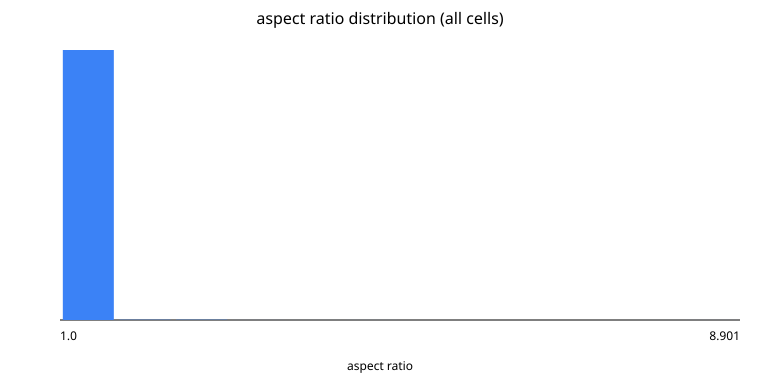

In [3]:
qc = quality_counts(surface)
println("cells scored: ", qc.num_cells, ", inverted: ", qc.num_inverted)

surfQ = attach_quality(surface)
ar = vec(cell_data(surfQ, "quality:aspect_ratio", 1))
arf = filter(isfinite, ar)
println("quality:aspect_ratio min=", round(minimum(arf); digits=4),
        " mean=", round(sum(arf)/length(arf); digits=4), " max=", round(maximum(arf); digits=4))

K = 12
edges = collect(range(minimum(arf), maximum(arf); length=K + 1))
counts = zeros(Int, K)
for v in arf
    b = clamp(Int(floor((v - edges[1]) / (edges[end] - edges[1]) * K)) + 1, 1, K)
    counts[b] += 1
end
histogram_chart(edges, counts, "aspect ratio distribution (all cells)", "aspect ratio")

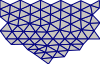

In [4]:
surfQCorner = attach_quality(viz_corner)
render(surfQCorner)  # plain -- flat-ABI gap, see the note above; distribution shown above instead

## Reordering / renumbering

`reorder` renumbers nodes and elements (RCM, or the Morton/Hilbert space-filling curves) as a *pure
permutation* -- geometry and data pass through untouched. `compute_bandwidth` measures the connectivity
bandwidth before and after.

In [5]:
before_bw = compute_bandwidth(mesh)
for method in ("rcm", "morton", "hilbert")
    rr = reorder(mesh, method)
    println(rpad(method, 8), ": bandwidth ", before_bw, " -> ", compute_bandwidth(rr.mesh))
end

rcm     : bandwidth 

50857 -> 1229
morton  : bandwidth 50857 -> 41980
hilbert : bandwidth 50857 -> 46625


## Comparison (diff)

`meshes_equal` is the boolean helper for regression tests; `diff` returns a structured report with an
overall verdict. First the canonical CI pattern -- write to another format, read it back, assert equal
within tolerance.

In [6]:
roundtrip_path = joinpath(mktempdir(), "surface.vtu")
mio.write(surface, roundtrip_path)
roundtrip = mio.read(roundtrip_path)
println("round-trip equal: ", meshes_equal(surface, roundtrip; atol=1e-10))

round-trip equal: true

Now a **localised deformation**: push a bump into the surface and let `diff` find it.

verdict          : different


points exceeding : 25843
worst point index: 36372 | max abs error: 0.049597


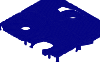

In [7]:
pts = points(surface)  # (3, n)
centre = vec(sum(pts; dims=2)) ./ size(pts, 2)
dist = [sqrt(sum((pts[:, i] .- centre) .^ 2)) for i in 1:size(pts, 2)]
maxd = maximum(dist)

deformed_pts = copy(pts)
err = zeros(size(pts, 2))
for i in 1:size(pts, 2)
    t = dist[i] / (0.25 * maxd)
    bump = 0.05 * exp(-(t * t))
    deformed_pts[3, i] += bump
    err[i] = bump
end
deformed = extract_surface(mesh)   # a fresh copy to mutate
set_points!(deformed, deformed_pts)

rep = mio.diff(surface, deformed; atol=1e-6)
println("verdict          : ", rep.verdict)
println("points exceeding : ", rep.points.num_exceeding)
println("worst point index: ", rep.points.worst_index, " | max abs error: ",
        round(rep.points.max_abs_error; digits=6))

# crop to a window centred on the deformation, where the bump is actually visible
half = 0.3 .* (viz_hi .- viz_lo)
bump_lo, bump_hi = centre .- half, centre .+ half
vis = extract_surface(mesh)
add_point_data!(vis, "abs_error", err)
vis_crop = crop_bbox(vis, bump_lo, bump_hi)
render(vis_crop)

`diff` also has an **unordered** mode that matches nodes by spatial proximity, so a mesh whose nodes
were merely *renumbered* still compares equal.

In [8]:
# Shuffle the point numbering (a random permutation), remapping connectivity in place -- cells stay in
# the same order, only the node indices change. A fixed permutation keeps the notebook reproducible.
n = num_points(surface)
perm = collect(n:-1:1)   # a simple, deterministic "shuffle": full reversal
inv = similar(perm)
for newid in 1:n
    inv[perm[newid]] = newid
end

origp = points(surface)
shufp = similar(origp)
for newid in 1:n
    shufp[:, newid] = origp[:, perm[newid]]
end

conn = connectivity(surface, 1)
shufconn = map(v -> inv[v], conn)

shuffled = Mesh()
set_points!(shuffled, shufp)
add_cell_block!(shuffled, cell_block_type(surface, 1), shufconn)

ordered = mio.diff(surface, shuffled)
unordered = mio.diff(surface, shuffled; unordered=true)
println("ordered   verdict: ", ordered.verdict)
println("unordered verdict: ", unordered.verdict)

ordered   verdict: different


unordered verdict: identical


## Format sniffing

In [9]:
println("sniffed format of the .vtu we wrote: ", sniff_format(roundtrip_path))

sniffed format of the .vtu we wrote: vtu


## Affine transform

`transform` moves the points (translate/scale/rotate/matrix) while carrying connectivity and data through.
Here: a 45-degree rotation about the x-axis.

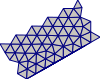

In [10]:
surfH = viz_corner
z = points(surfH)[3, :]
add_point_data!(surfH, "height", z)

theta = pi / 4
Rmat = [1.0 0.0 0.0 0.0
        0.0 cos(theta) -sin(theta) 0.0
        0.0 sin(theta) cos(theta) 0.0
        0.0 0.0 0.0 1.0]
rotated = mio.transform(surfH, Rmat)
render(rotated)

## Clean (weld / prune / de-dup)

Build a deliberately messy mesh by duplicating every point and cell of the surface, then `clean(...,
weld=true)` fuses the coincident points and drops the resulting duplicate cells.

In [11]:
n = num_points(surface)
sp = points(surface)
dup_pts = hcat(sp, sp)

conn = connectivity(surface, 1)
nc = size(conn, 2)
dup_conn = hcat(conn, conn .+ n)

dirty = Mesh()
set_points!(dirty, dup_pts)
add_cell_block!(dirty, cell_block_type(surface, 1), dup_conn)

cr = clean(dirty; weld=true, atol=1e-8)
println("points: ", num_points(dirty), " -> ", num_points(cr.mesh),
        " (welded ", cr.points_welded, ", duplicate cells dropped ", cr.cells_dropped_duplicate, ")")

points: 58302

 -> 29151 (welded 29151, duplicate cells dropped 58394)


## Crop (bounding box / half-space)\n\nKeep the half of the surface below the mid-plane in x.

kept cells: 17122 (from 58394)


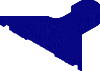

In [12]:
lo, hi = collect(vs.bbox_min), collect(vs.bbox_max)
mid = (lo .+ hi) ./ 2
crop_hi = [mid[1], hi[2], hi[3]]
cropped = crop_bbox(surface, lo, crop_hi)
println("kept cells: ", num_cells(cropped), " (from ", num_cells(surface), ")")
render(cropped)

## Merge / weld

`merge` combines several meshes. By default it concatenates; with `weld=true` it fuses coincident points.
Merging the surface with an exact copy of itself makes the difference unmistakable: welding recovers the
original point count exactly.

In [13]:
surface_copy = extract_surface(mesh)  # an independent, identical copy

plain = mio.merge([surface, surface_copy]; source_tag=true)
welded = mio.merge([surface, surface_copy]; weld=true, atol=1e-8, source_tag=true)
println("inputs       : ", num_points(surface), " + ", num_points(surface_copy), " = ",
        num_points(surface) + num_points(surface_copy), " points")
println("concatenated : ", num_points(plain), " points")
println("welded       : ", num_points(welded), " points (",
        num_points(plain) - num_points(welded), " fused)")

inputs       : 29151

 + 29151 = 58302 points
concatenated : 58302 points
welded       : 29151 points (29151 fused)


## Split (partition into pieces)

`split` partitions a mesh by type, connected component, or region. Tag each surface cell left/right of the
mid-plane and split by that region.

In [14]:
conn = connectivity(surface, 1)
p = points(surface)
npc = size(conn, 1)
region = Int64[sum(p[1, conn[:, c]]) / npc > mid[1] ? 1 : 0 for c in 1:size(conn, 2)]

surfR = extract_surface(mesh)
append_cell_data!(surfR, "region", region)

pieces = mio.split(surfR; by="region", tag="region")
println("pieces: ", length(pieces))
for (key, piece) in pieces
    println("  ", key, ": ", num_cells(piece), " cells")
end

pieces: 2


  1: 41039 cells
  0: 17355 cells


## Geometric statistics

`stats` returns geometric measures -- the geometric complement to the topological cell-count summary
above.

bbox     : (-3.505, -3.185, 0.0

) -> (0.0, 0.625, 0.382)
centroid : (-1.34617, -1.26344, 0.13892)
area     : 41.681
volume   : signed 1.22995 | unsigned 1.22995 | inverted 0


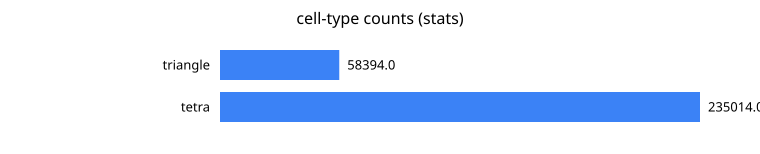

In [15]:
s = stats(mesh)
println("bbox     : (", join(round.(s.bbox_min; digits=3), ", "), ") -> (",
        join(round.(s.bbox_max; digits=3), ", "), ")")
println("centroid : (", join(round.(s.centroid; digits=5), ", "), ")")
println("area     : ", round(s.total_area; digits=3))
println("volume   : signed ", round(s.signed_volume; digits=5), " | unsigned ",
        round(s.unsigned_volume; digits=5), " | inverted ", s.num_inverted)

type_names = cell_block_types(mesh)
type_counts = Float64[cell_block_info(mesh, i).num_cells for i in 1:num_cell_blocks(mesh)]
bar_chart(type_names, type_counts, "cell-type counts (stats)")

## Cell conversion (linearize / simplexify / elevate)

`convert_cells` rewrites which cell *types* a mesh is built from. Take a small hexahedral block and
**simplexify** it: each hexahedron becomes 6 tetrahedra reusing the parent's own corner nodes, so no
points are added and the volume is conserved exactly.

before: 27

 hexahedron | points 64 | volume 27.0
after : 162 tetra | points 64 | volume 27.0
inverted cells after simplexify: 0


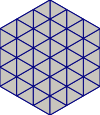

In [16]:
hexes = hex_block(3)
simp = convert_cells(hexes, "simplexify")

before = stats(hexes)
after = stats(simp.mesh)
println("before: ", before.num_cells, " ", cell_block_type(hexes, 1), " | points ", num_points(hexes),
        " | volume ", round(before.unsigned_volume; digits=4))
println("after : ", after.num_cells, " ", cell_block_type(simp.mesh, 1), " | points ",
        num_points(simp.mesh), " | volume ", round(after.unsigned_volume; digits=4))
println("inverted cells after simplexify: ", after.num_inverted)
render(simp.mesh)

In [17]:
# elevate does the opposite: linear cells gain a node per unique edge.
elevated = convert_cells(hexes, "elevate")
println("elevate    : ", cell_block_type(hexes, 1), " -> ", cell_block_type(elevated.mesh, 1),
        " | points ", num_points(hexes), " -> ", num_points(elevated.mesh))

back = convert_cells(elevated.mesh, "linearize")
println("linearize  : ", cell_block_type(elevated.mesh, 1), " -> ", cell_block_type(back.mesh, 1),
        " | points ", num_points(elevated.mesh), " -> ", num_points(back.mesh))
println("round-trip recovers the original mesh: ", meshes_equal(hexes, back.mesh))

elevate    : hexahedron -> hexahedron20 | points 64 -> 208
linearize  : hexahedron20 -> hexahedron | points 208 -> 64
round-trip recovers the original mesh: true


## Uniform refinement

`refine` subdivides every cell into congruent children of the **same** type, inserting shared nodes at the
midpoints of edges, quad faces and (hexahedron only) the body -- no hanging nodes.

coarse: 8 cells | 27 points | volume 8.0
fine  : 64 cells | 125 points | volume 8.0
points: 125 (a conforming 5x5x5 lattice = 125) vs 216 if every cell kept its own copy
max interpolation error on a linear field: 0.0

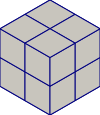

In [18]:
coarse = hex_block(2)
height = points(coarse)[3, :]
add_point_data!(coarse, "height", height)

fine = refine(coarse)
coarse_stats, fine_stats = stats(coarse), stats(fine.mesh)
println("coarse: ", coarse_stats.num_cells, " cells | ", num_points(coarse), " points | volume ",
        coarse_stats.unsigned_volume)
println("fine  : ", fine_stats.num_cells, " cells | ", num_points(fine.mesh), " points | volume ",
        fine_stats.unsigned_volume)
println("points: ", num_points(fine.mesh), " (a conforming 5x5x5 lattice = 125) vs ",
        cell_block_info(coarse, 1).num_cells * 27, " if every cell kept its own copy")

fh = point_data(fine.mesh, "height")
fp = points(fine.mesh)
refine_err = maximum(abs.(fh .- fp[3, :]))
println("max interpolation error on a linear field: ", refine_err)

render(coarse)

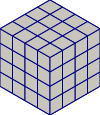

In [19]:
render(fine.mesh)

## Decimation (QEM edge collapse)

`decimate` is `refine`'s inverse: it *reduces* a surface mesh's face count by greedy quadric-error-metric
(Garland-Heckbert) edge collapse. Boundary and feature vertices are pinned by default, and the link
condition plus a normal-flip guard reject anything that would change topology or fold the surface.

corner : 107 triangles | 71 points
coarse : 53 triangles | 44 points
removed 54 faces, rejected 34 collapses, max quadric error 0.0
total area: 0.040713 -> 0.040713


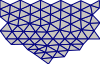

In [20]:
dec = decimate(viz_corner; ratio=0.5)

corner_faces_in = sum(cell_block_info(viz_corner, i).num_cells for i in 1:num_cell_blocks(viz_corner))
corner_faces_out = sum(cell_block_info(dec.mesh, i).num_cells for i in 1:num_cell_blocks(dec.mesh))
println("corner : ", corner_faces_in, " triangles | ", num_points(viz_corner), " points")
println("coarse : ", corner_faces_out, " triangles | ", num_points(dec.mesh), " points")
println("removed ", dec.faces_removed, " faces, rejected ", dec.collapses_rejected,
        " collapses, max quadric error ", round(dec.max_error_applied; digits=6))
println("total area: ", round(stats(viz_corner).total_area; digits=6), " -> ",
        round(stats(dec.mesh).total_area; digits=6))

render(attach_quality(viz_corner))

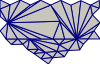

In [21]:
render(attach_quality(dec.mesh))

## Partitioning (N balanced parts)

`partition` decomposes a mesh into exactly N balanced pieces -- the count-driven complement to the
criterion-driven `split`. `method="sfc"` (pinned here for determinism) orders cells along a Hilbert curve
of their centroids and cuts it into contiguous ranges.

part sizes: 

[48902, 48901, 48901, 48902, 48901, 48901] (max-min = 1 cells)
piece cell counts: 

[48902, 48901, 48901, 48902, 48901, 48901]


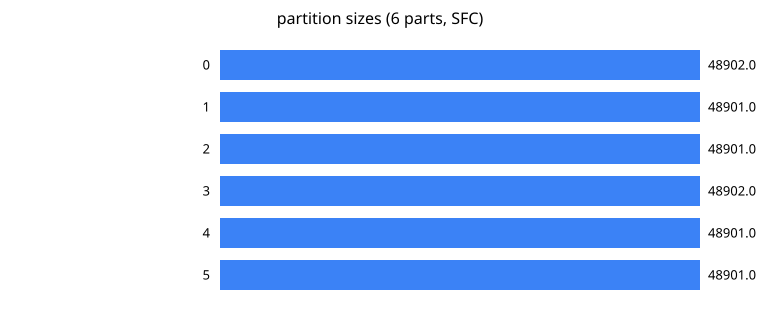

In [22]:
labels = partition_labels(mesh, 6; method="sfc")
sizes = [count(==(p), labels) for p in 0:5]
println("part sizes: ", sizes, " (max-min = ", maximum(sizes) - minimum(sizes), " cells)")

parts = partition(mesh, 6; method="sfc")
println("piece cell counts: ", [num_cells(p.mesh) for p in parts])

type_names_p = string.(0:5)
bar_chart(type_names_p, Float64.(sizes), "partition sizes (6 parts, SFC)")

## Smoothing (Laplacian / Taubin)

`smooth` relaxes each free node toward the centroid of its edge neighbours. **Laplacian** shrinks the mesh
(unconditionally low-pass); **Taubin** (the default) follows every `+lambda` pass with a larger `-mu` pass,
giving the pair a pass band that leaves the volume essentially intact. Below: a jittered hex block, several
cells tangled, before and after -- min scaled Jacobian recovers from negative (inverted) to positive.

points 125

 -> 125   cells 64 -> 64 (unchanged: smooth only moves nodes)
min scaled Jacobian : -0.8018 -> 0.927
inverted cells      : 0 -> 0
volume              : 64.0 -> 64.0 (the exact block is 64)
nodes moved: 27, max displacement: 0.9904, skipped by the inversion guard: 0


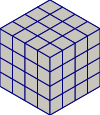

In [23]:
using Random
rough = hex_block(4)
p = points(rough)
rng = MersenneTwister(3)
for i in 1:size(p, 2)
    interior = all(0.0 .< p[:, i] .< 4.0)
    if interior
        p[:, i] .+= randn(rng, 3) .* 0.35
    end
end
set_points!(rough, p)

relaxed = smooth(rough; iterations=20)

q0_ok = attach_quality(rough)
q1_ok = attach_quality(relaxed.mesh)
sj0 = filter(isfinite, vec(cell_data(q0_ok, "quality:scaled_jacobian", 1)))
sj1 = filter(isfinite, vec(cell_data(q1_ok, "quality:scaled_jacobian", 1)))
s0, s1 = stats(rough), stats(relaxed.mesh)

println("points ", num_points(rough), " -> ", num_points(relaxed.mesh), "   cells ", s0.num_cells,
        " -> ", s1.num_cells, " (unchanged: smooth only moves nodes)")
println("min scaled Jacobian : ", round(minimum(sj0); digits=4), " -> ", round(minimum(sj1); digits=4))
println("inverted cells      : ", s0.num_inverted, " -> ", s1.num_inverted)
println("volume              : ", round(s0.unsigned_volume; digits=4), " -> ",
        round(s1.unsigned_volume; digits=4), " (the exact block is 64)")
println("nodes moved: ", relaxed.num_nodes_moved, ", max displacement: ",
        round(relaxed.max_displacement; digits=4), ", skipped by the inversion guard: ",
        relaxed.num_skipped_inversion)

render(attach_quality(extract_surface(rough)))

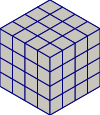

In [24]:
render(attach_quality(extract_surface(relaxed.mesh)))

## Field interpolation (cross-mesh transfer)

`interpolate(source, target)` is the first **two-mesh** operation that moves *data*: a copy of the target
with the source's arrays sampled onto it. `method="barycentric"` simplexifies the source and interpolates
linearly -- exact on a linear field.

transferred 'f' from 343

 onto 15625 points
max |error| on a linear field: 3.552713678800501e-15


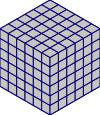

In [25]:
interp_coarse = hex_block(6; spacing=1.0 / 6.0)
pc = points(interp_coarse)
f = @. sin(4.0 * pc[1, :]) * cos(4.0 * pc[2, :]) + pc[3, :]
add_point_data!(interp_coarse, "f", f)

interp_fine = hex_block(24; spacing=1.0 / 24.0)
mapped = interpolate(interp_coarse, interp_fine; method="barycentric")
println("transferred \'f\' from ", num_points(interp_coarse), " onto ", num_points(mapped), " points")

lin = @. 2 * pc[1, :] + 3 * pc[2, :] + 5 * pc[3, :]
add_point_data!(interp_coarse, "lin", lin)
lin_mapped = interpolate(interp_coarse, interp_fine; method="barycentric", arrays=["lin"])
mlin = point_data(lin_mapped, "lin")
mp2 = points(lin_mapped)
lin_exact = @. 2 * mp2[1, :] + 3 * mp2[2, :] + 5 * mp2[3, :]
println("max |error| on a linear field: ", maximum(abs.(mlin .- lin_exact)))

render(interp_coarse)

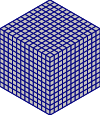

In [26]:
fine_lo, fine_hi = [0.0, 0.0, 0.0], [0.5, 0.5, 0.5]
mapped_corner = crop_bbox(mapped, fine_lo, fine_hi)
render(mapped_corner)

## Cross-section (slice)

`slice` computes the planar **cross-section** of a mesh -- the intersection with a plane, one topological
dimension below the cut cells. The input is simplexified first (marching tetrahedra), cut points on shared
edges are deduped (watertight), and `point_data` is interpolated at the cut. Unlike `crop`, which keeps
whole cells on one side, `slice` computes the intersection and lowers the dimension.

section: 289 points, 128 faces


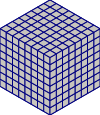

In [27]:
slice_vol = hex_block(8; spacing=1.0 / 8.0)
ps = points(slice_vol)
field = @. sin(6.0 * ps[1, :]) * cos(6.0 * ps[2, :]) + ps[3, :]
add_point_data!(slice_vol, "f", field)

section = slice(slice_vol, [0.5, 0.5, 0.5], [0.0, 0.0, 1.0])
nfaces = sum(cell_block_info(section, i).num_cells for i in 1:num_cell_blocks(section))
println("section: ", num_points(section), " points, ", nfaces, " faces")

render(slice_vol)

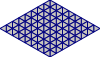

In [28]:
render(section)

## Isosurfaces / contours

`isosurface` computes the **level set** of a scalar `point_data` field -- the locus where the array equals
a given isovalue, one topological dimension below the cut cells. It is the *data-driven* sibling of
`slice`. Several isovalues land in one mesh, tagged per cell with a Float64 `iso:value` and an Int64
`iso:index`. A `cell_data` name is rejected -- it is piecewise constant and has no level set.

contours: 1206

 points, 1836 faces
distinct values of r on the contours: 

[0.2, 0.32, 0.44]
  contour 0: 228 faces
  contour 1: 588 faces
  contour 2: 1020 faces


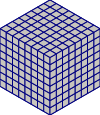

In [29]:
iso_vol = hex_block(8; spacing=1.0 / 8.0)
pv = points(iso_vol)
radius = @. sqrt((pv[1, :] - 0.5)^2 + (pv[2, :] - 0.5)^2 + (pv[3, :] - 0.5)^2)
add_point_data!(iso_vol, "r", radius)

shells = isosurface(iso_vol, "r", [0.20, 0.32, 0.44])
nfaces = sum(cell_block_info(shells, i).num_cells for i in 1:num_cell_blocks(shells))
println("contours: ", num_points(shells), " points, ", nfaces, " faces")

levels = sort(unique(round.(point_data(shells, "r"); digits=10)))
println("distinct values of r on the contours: ", levels)

iso_pieces = mio.split(shells; by="region", tag="iso:index")
for (key, piece) in iso_pieces
    n = sum(cell_block_info(piece, i).num_cells for i in 1:num_cell_blocks(piece))
    println("  contour ", key, ": ", n, " faces")
end

render(iso_vol)

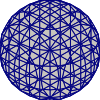

In [30]:
render(shells)

Every operation shown here is also exposed through the C API, the Fortran module, and the
WebAssembly build, and as a `meshioplusplus` CLI verb.

## Data operations

The operations above reshape *geometry*. The **data operations** act on
`point_data`/`cell_data`/`field_data` and never touch geometry. A quick walk through all five on the
surface mesh.

In [31]:
surfD = viz_corner
pD = points(surfD)
cx, cy = sum(pD[1, :]) / size(pD, 2), sum(pD[2, :]) / size(pD, 2)

vel = Matrix{Float64}(undef, 3, size(pD, 2))
height2 = Vector{Float64}(undef, size(pD, 2))
for i in 1:size(pD, 2)
    rx, ry, rz = pD[1, i] - cx, pD[2, i] - cy, pD[3, i]
    vel[:, i] = [-ry, rx, 0.3 * rz]
    height2[i] = pD[3, i]
end
add_point_data!(surfD, "velocity", vel)
add_point_data!(surfD, "height", height2)

function show_data_info(m, title)
    rows = data_info(m)
    println(title)
    for a in rows
        println("  ", a.location, " ", a.name, " comp=", a.num_components, " entries=", a.num_entries,
                " min=", round(a.min; digits=6), " max=", round(a.max; digits=6),
                " mean=", round(a.mean; digits=6))
    end
    rows
end
show_data_info(surfD, "before:");

before:


  point height comp=1 entries=71 min=0.0 max=0.125244 mean=0.045108
  point velocity comp=3 entries=71 min=-0.102238 max=0.099902 mean=0.004511


speed range: 0.015887 -> 0.135876


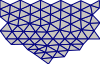

In [32]:
# data_calc: a small expression language (+ - * /, abs/sqrt/min/max/norm).
with_speed = data_calc(surfD, "norm(velocity)", "speed")
sp2 = point_data(with_speed, "speed")
println("speed range: ", round(minimum(sp2); digits=6), " -> ", round(maximum(sp2); digits=6))
render(with_speed)

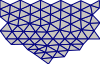

In [33]:
# data_point_to_cell / data_cell_to_point: move between locations. The round trip acts as a
# smoothing pass.
to_cell = data_point_to_cell(with_speed, ["speed"]; suffix="_cell")
back2 = data_cell_to_point(to_cell, ["speed_cell"]; weight=:measure)
render(with_speed)

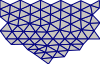

In [34]:
render(back2)

normalized range: 0.0 -> 1.0


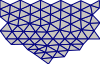

In [35]:
# data_condition: clamp / normalize / standardize, without touching geometry.
normd = data_condition(with_speed, :point, ["speed"]; mode=:normalize, suffix="_n")
nd = point_data(normd, "speed_n")
println("normalized range: ", round(minimum(nd); digits=6), " -> ", round(maximum(nd); digits=6))
render(normd)

In [36]:
# rename / drop: tidy up and confirm the geometry never moved.
tidy = data_rename(normd, :point, "speed_n", "speed_normalized")
tidy = data_drop(tidy, :point, ["speed"])
show_data_info(tidy, "after rename + drop:")

same_pts = num_points(surfD) == num_points(tidy)
same_cells = num_cells(surfD) == num_cells(tidy)
println("\ngeometry unchanged -- points: ", same_pts, " | cell count: ", same_cells)

after rename + drop:
  point height comp=1 entries=71 min=0.0 max=0.125244 mean=0.045108
  point speed_normalized comp=1 entries=71 min=0.0 max=1.0 mean=0.478844
  point velocity comp=3 entries=71 min=-0.102238 max=0.099902 mean=0.004511

geometry unchanged -- points: true | cell count: true


## Selective reads: loading only what you need

`ReadOptions` narrow a read: `points_only` (geometry only, no data arrays) and `arrays` (only the named
arrays). `read_metadata` skips the heavy arrays entirely and reports whether it had to fall back to a full
read (`fell_back`).

In [37]:
sel_mesh = extract_surface(mesh)
psel = points(sel_mesh)
cxs, cys, czs = sum(psel[1, :])/size(psel,2), sum(psel[2, :])/size(psel,2), sum(psel[3, :])/size(psel,2)
radius = @. sqrt((psel[1, :] - cxs)^2 + (psel[2, :] - cys)^2 + (psel[3, :] - czs)^2)
add_point_data!(sel_mesh, "radius", radius)
sel_path = joinpath(mktempdir(), "selective.vtu")
mio.write(sel_mesh, sel_path)

full = mio.read(sel_path)
bare = mio.read(sel_path; options=ReadOptions(points_only=true))
meta = read_metadata(sel_path)

println("full read      : point_data arrays=", num_point_data(full))
println("points_only    : point_data arrays=", num_point_data(bare))
println("read_metadata  : ", meta.num_points, " points, ", meta.num_cells, " cells, arrays=",
        length(meta.point_data_names))
println("summary was cheap (no fallback): ", !meta.fell_back)
println()
println("same geometry, no data arrays: ", num_point_data(bare) == 0)

full read      : point_data arrays=1


points_only    : point_data arrays=0
read_metadata  : 29151 points, 58394 cells, arrays=1
summary was cheap (no fallback): true

same geometry, no data arrays: true


Reading the numbers honestly: `points_only` still decodes and transfers connectivity, which is never
skipped, so the win depends on how data-heavy a given file is. `read_metadata` is the consistent win: it
decodes neither coordinates nor connectivity, only the array headers.